**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

In [2]:
### set file directory
txt_prefix = "variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs"
txt_folder = "motifcount_pilot_jvierstra_v2.1beta"
txt_fdiry  = file.path(FD_RES, "analysis_variant_motif_richard", txt_folder)
txt_fname  = paste(txt_prefix, "pilot.motif.count.tsv", sep = ".")
txt_fpath  = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_motif_count_import = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 2516    7


Group_Type,Group,Type,Motif_Name,Count_Total,Count_Gain,Count_Loss
Top_Ori,Top,Ori,AC0001:GATA/PROP:GATA,99999,361,261
Top_Ori,Top,Ori,AC0002:PROP/ALX:Homeodomain,99999,812,591
Top_Ori,Top,Ori,AC0003:HNF1A/HNF1B:Homeodomain,99999,429,466
Top_Ori,Top,Ori,AC0004:ZSCAN:C2H2_ZF,99999,185,255
Top_Ori,Top,Ori,"AC0005:POU3F/POU1F:Homeodomain,POU",99999,685,1027
Top_Ori,Top,Ori,AC0006:MEOX:Homeodomain,99999,631,783


In [3]:
dat = dat_motif_count_import 
dat = dat %>% tidyr::pivot_longer(
    cols      = c(Count_Gain, Count_Loss),
    names_to  = "Direction",
    values_to = "Count"
)
lst = split(dat, dat$Direction)

### assign and show
lst_dat_motif_count = lst
res = lapply(lst, dim)
print(res)

$Count_Gain
[1] 2516    7

$Count_Loss
[1] 2516    7



In [4]:
lst = lst_dat_motif_count 
lst = lapply(lst, function(dat){
    ### split by motifs
    lst = split(dat, dat$Motif_Name)

    ### loop through motifs and run logistic regression
    lst = lapply(lst, function(dat){
        ### ensure factor level
        dat = dat %>% dplyr::mutate(
            Group = factor(Group, levels = c("Low","Top")),
            Type  = factor(Type,  levels = c("Nuc","Ori"))
        )
        
        ### pseudo-count
        dat$Count = dat$Count + 0.5
        dat$Count_Total = dat$Count_Total + 1
        
        ### sanity check
        stopifnot(all(dat$Count <= dat$Count_Total))

        ### run logistic regression
        fit = suppressWarnings(glm(
            cbind(Count, Count_Total - Count) ~ Group * Type,
            family = binomial,
            data = dat
        ))
        return(fit)
    })
    return(lst)
})

lol_fit_motif_count = lst
res = lapply(lst, length)
print(res)

$Count_Gain
[1] 629

$Count_Loss
[1] 629



In [98]:
lol_fit = lol_fit_motif_count
lst_res = lapply(names(lol_fit), function(txt_direction){

    ### get the list of regression fit for all motifs
    lst_fit = lol_fit[[txt_direction]]

    ### get coefficient of each fit model
    lst_res_direction = lapply(names(lst_fit), function(txt_motif){

        ### get the fit of a motif and summarize
        fit = lst_fit[[txt_motif]]
        res = summary(fit)$coefficients

        ### get coefficient
        txt = "GroupTop:TypeOri"
        num_beta_est  = res[txt, "Estimate"]
        num_beta_se   = res[txt, "Std. Error"]
        num_beta_pval = res[txt, "Pr(>|z|)"]

        ### arrange result table
        dat = data.frame(
            Direction = txt_direction, # "Count_Gain" or "Count_Loss"
            Motif_Name = txt_motif,    
            Beta_Est   = num_beta_est,
            OddsRatio  = exp(num_beta_est),
            Beta_SE    = num_beta_se,
            Beta_Z     = num_beta_est / num_beta_se,
            Beta_Pval  = num_beta_pval
        )
        return(dat)
    })

    ### concat results of a direction
    dat_direction = dplyr::bind_rows(lst_res_direction)
    
    ### adjust pvalue (BH) within direction
    dat_direction = dat_direction %>% 
        dplyr::mutate(
            Beta_Padj = p.adjust(Beta_Pval, method = "BH")
        )
    return(dat_direction)
})

### concat results across for both direction
dat = dplyr::bind_rows(lst_res)

### assign and show
dat_fit_motif_enrich = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 1258    8


Direction,Motif_Name,Beta_Est,OddsRatio,Beta_SE,Beta_Z,Beta_Pval,Beta_Padj
Count_Gain,AC0001:GATA/PROP:GATA,0.1921645,1.2118699,0.0928337,2.069986,0.0384537,0.0666318
Count_Gain,AC0002:PROP/ALX:Homeodomain,0.8336586,2.3017246,0.0703133,11.856343,0.0000000,0.0000000
Count_Gain,AC0003:HNF1A/HNF1B:Homeodomain,0.0813782,1.0847811,0.0761162,1.069131,0.2850106,0.3719329
Count_Gain,AC0004:ZSCAN:C2H2_ZF,-0.2531942,0.7763171,0.1324355,-1.911830,0.0558980,0.0922831
Count_Gain,"AC0005:POU3F/POU1F:Homeodomain,POU",-0.1404850,0.8689367,0.0655264,-2.143943,0.0320374,0.0567649
Count_Gain,AC0006:MEOX:Homeodomain,0.2092501,1.2327532,0.0696715,3.003379,0.0026700,0.0058321


In [99]:
dat = dat_fit_motif_enrich

vec1 = dat$Direction
res = table(vec1)
print(res)
cat("\n")

vec2 = ifelse(dat$Beta_Padj < 0.001, "Signif", "NotSignif")
res = table(vec1, vec2)
print(res)

vec1
Count_Gain Count_Loss 
       629        629 

            vec2
vec1         NotSignif Signif
  Count_Gain       395    234
  Count_Loss       380    249


In [100]:
dat = dat_fit_motif_enrich
eps = min(dat$Beta_Padj[dat$Beta_Padj > 0]) / 10

dat = dat %>% 
    dplyr::mutate(Log10Beta  = Beta_Est / log(10)) %>%
    dplyr::mutate(Beta_Padj  = pmax(Beta_Padj, eps)) %>%
    dplyr::mutate(NLog10Padj = -log10(Beta_Padj))

dat_fit_motif_enrich_arrange = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1258   10


Direction,Motif_Name,Beta_Est,OddsRatio,Beta_SE,Beta_Z,Beta_Pval,Beta_Padj,Log10Beta,NLog10Padj
Count_Gain,AC0001:GATA/PROP:GATA,0.1921645,1.211870,0.0928337,2.069986,0.0384537,0.0666318,0.0834560,1.1763184
Count_Gain,AC0002:PROP/ALX:Homeodomain,0.8336586,2.301725,0.0703133,11.856343,0.0000000,0.0000000,0.3620533,30.4065576
Count_Gain,AC0003:HNF1A/HNF1B:Homeodomain,0.0813782,1.084781,0.0761162,1.069131,0.2850106,0.3719329,0.0353421,0.4295354


## Export results

In [101]:
txt_prefix = "variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs"
txt_folder = "motifcount_pilot_jvierstra_v2.1beta"
txt_fdiry  = file.path(FD_RES, "analysis_variant_motif_richard", txt_folder)
txt_fname  = paste(txt_prefix, "pilot.motif.enrich.tsv", sep = ".")
txt_fpath  = file.path(txt_fdiry, txt_fname)

dat = dat_fit_motif_enrich_arrange
write_tsv(dat, txt_fpath)

In [8]:
THEME_TEXT = theme(
    text = element_text(size = 16),
    
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    
    axis.text.x  = element_text(size = 16),
    axis.text.y  = element_text(size = 16),
    
    strip.text   = element_text(size = 16),
    
    legend.title = element_text(size = 16),
    legend.text  = element_text(size = 16)
)

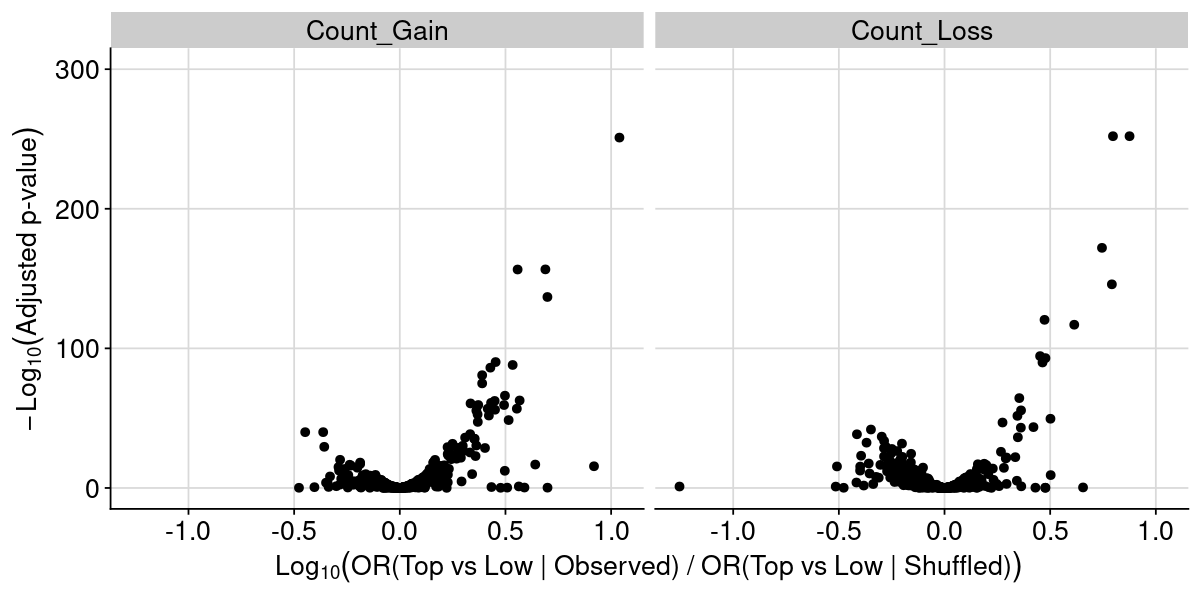

In [9]:
dat = dat_res_motif_count
eps = min(dat$Beta_Padj[dat$Beta_Padj > 0]) / 10

dat = dat %>% 
    dplyr::mutate(log10Beta  = Beta_Est / log(10)) %>%
    dplyr::mutate(Beta_Padj  = pmax(Beta_Padj, eps)) %>%
    dplyr::mutate(nlog10Padj = -log10(Beta_Padj))

gpt = ggplot(dat, aes(x = log10Beta, y = nlog10Padj)) +
    geom_point() +
    theme_cowplot() +
    background_grid() +
    THEME_TEXT +
    facet_grid(.~Direction) +
    ylim(0, 300) +
    labs(
        x = expression( Log[10]("OR(Top vs Low | Observed) / OR(Top vs Low | Shuffled)")),
        y = expression(-Log[10]("Adjusted p-value"))
    ) 

options(repr.plot.height=5, repr.plot.width=10)
print(gpt)

In [13]:
dat = dat_res_motif_count
eps = min(dat$Beta_Padj[dat$Beta_Padj > 0]) / 10

num_cut_padj  = -log10(1e-5)
num_cut_zcore = 3

dat = dat %>% 
    dplyr::mutate(log10Beta  = Beta_Est / log(10)) %>%
    dplyr::mutate(Beta_Padj  = pmax(Beta_Padj, eps)) %>%
    dplyr::mutate(nlog10Padj = -log10(Beta_Padj))

dat = dat %>%
    dplyr::mutate(
        Hit_Type = dplyr::case_when(
            (nlog10Padj > num_cut_padj) & (Beta_Z > num_cut_zcore) & Direction == "Count_Gain" ~ "Gain_Hit",
            (nlog10Padj > num_cut_padj) & (Beta_Z > num_cut_zcore) & Direction == "Count_Loss" ~ "Loss_Hit",
            TRUE ~ "NotSignif"
        )
    )

dat_res_motif_label = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1258   11


Direction,Motif_Name,Beta_Est,OddsRatio,Beta_SE,Beta_Z,Beta_Pval,Beta_Padj,log10Beta,nlog10Padj,Hit_Type
Count_Gain,AC0001:GATA/PROP:GATA,0.1921645,1.211870,0.0928337,2.069986,0.0384537,0.0666318,0.0834560,1.1763184,NotSignif
Count_Gain,AC0002:PROP/ALX:Homeodomain,0.8336586,2.301725,0.0703133,11.856343,0.0000000,0.0000000,0.3620533,30.4065576,Gain_Hit
Count_Gain,AC0003:HNF1A/HNF1B:Homeodomain,0.0813782,1.084781,0.0761162,1.069131,0.2850106,0.3719329,0.0353421,0.4295354,NotSignif


Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


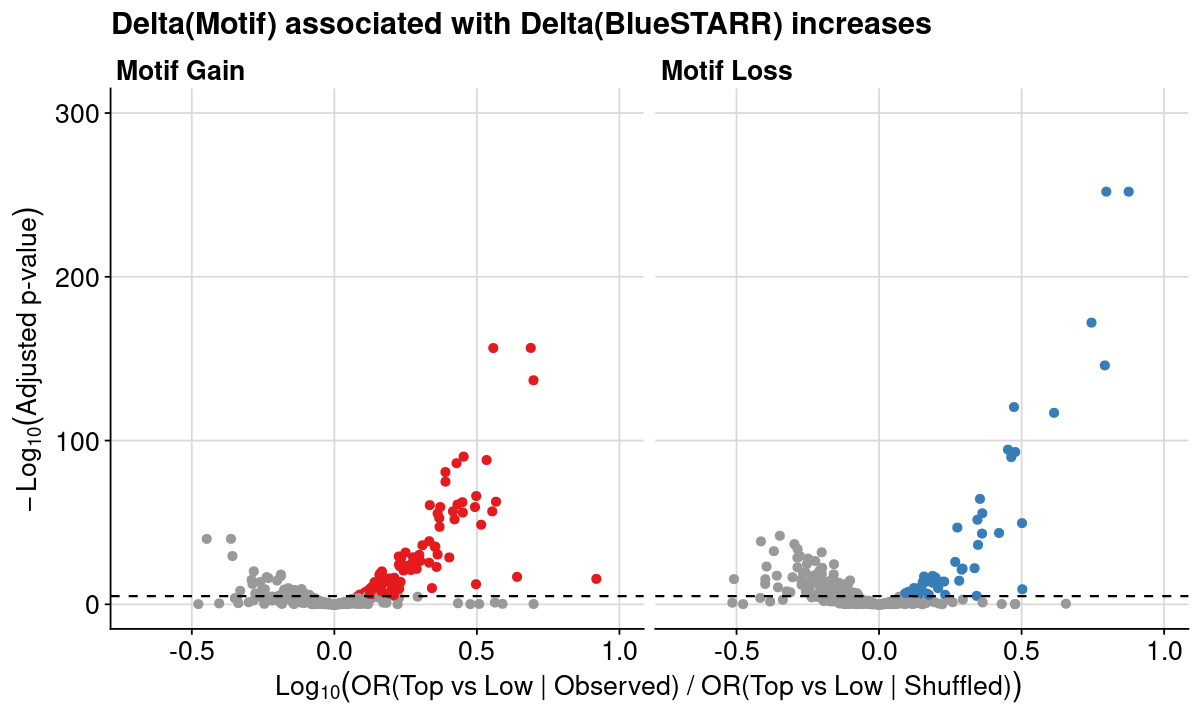

In [14]:
dat = dat_res_motif_label

gpt = ggplot(dat, aes(x = log10Beta, y = nlog10Padj)) +
    geom_point(aes(color = Hit_Type), size = 2) +
    geom_hline(yintercept = num_cut_padj, linetype = "dashed") +
    theme_cowplot() +
    background_grid() +
    THEME_TEXT +
    theme(
        strip.background = element_blank(),
        strip.text = element_text(size = 16, hjust = 0, face = "bold")
    ) +
    facet_grid(
        . ~ Direction,
        labeller = labeller(
            Direction = c(
                "Count_Gain" = "Motif Gain",
                "Count_Loss" = "Motif Loss"
            )
        )
    ) +
    scale_color_manual(
        values = c(
            "NotSignif" = "grey60",
            "Gain_Hit"  = "#e41a1c",
            "Loss_Hit"  = "#377eb8"
        ),
        guide = "none"
    ) +
    ylim(0, 300) +
    xlim(-0.7, 1.0) +
    labs(
        title = "Delta(Motif) associated with Delta(BlueSTARR) increases",
        x = expression(Log[10]("OR(Top vs Low | Observed) / OR(Top vs Low | Shuffled)")),
        y = expression(-Log[10]("Adjusted p-value"))
    )

options(repr.plot.height=6, repr.plot.width=10)
print(gpt)

In [90]:
dat = dat_res_motif_label
dat = dat %>% dplyr::filter(Hit_Type != "NotSignif")
dat = dat %>% dplyr::filter(Hit_Type == "Gain_Hit")
dat = dat %>% 
    dplyr::select(Direction, Motif_Name, OddsRatio, Beta_Z, nlog10Padj, Hit_Type) %>%	
    dplyr::arrange(-Beta_Z)
print(dim(dat))
fun_display_table(head(dat, 50))

[1] 110   6


Direction,Motif_Name,OddsRatio,Beta_Z,nlog10Padj,Hit_Type
Count_Gain,AC0403:DBP/HLF:bZIP,10.947598,34.077646,251.00230,Gain_Hit
Count_Gain,AC0402:CEBPB/CEBPE:bZIP,4.885771,26.935911,156.58110,Gain_Hit
Count_Gain,AC0059:YY/ZFP:C2H2_ZF,3.610114,26.913683,156.49691,Gain_Hit
Count_Gain,AC0547:ATF/CREB:bZIP,4.995391,25.164739,136.81449,Gain_Hit
Count_Gain,AC0626:ELF/ETV:Ets,2.840854,20.458867,90.20058,Gain_Hit
Count_Gain,AC0242:FOSL/JUND:bZIP,3.420572,20.213770,88.10986,Gain_Hit
Count_Gain,AC0060:YY/MZF:C2H2_ZF,2.682824,19.984404,86.16977,Gain_Hit
Count_Gain,AC0622:ELF/SPIB:Ets,2.453268,19.347858,80.77710,Gain_Hit
Count_Gain,AC0061:YY:C2H2_ZF,2.453431,18.634120,74.92533,Gain_Hit
Count_Gain,AC0390:CREB/JUND:bZIP,3.144637,17.508865,66.11281,Gain_Hit


In [89]:
dat = dat_res_motif_label
dat = dat %>% dplyr::filter(Hit_Type != "NotSignif")
dat = dat %>% dplyr::filter(Hit_Type == "Loss_Hit")
dat = dat %>% 
    dplyr::select(Direction, Motif_Name, OddsRatio, Beta_Z, nlog10Padj, Hit_Type) %>%	
    dplyr::arrange(-Beta_Z)
print(dim(dat))
fun_display_table(head(dat, 50))

[1] 59  6


Direction,Motif_Name,OddsRatio,Beta_Z,nlog10Padj,Hit_Type
Count_Loss,AC0606:SNAI/ZEB:C2H2_ZF,7.509257,43.764465,252.002297,Loss_Hit
Count_Loss,AC0526:GFI/GFI1B:C2H2_ZF,6.268511,39.157639,252.002297,Loss_Hit
Count_Loss,AC0608:TFAP/MYOD:bHLH,5.561260,28.208431,172.014896,Loss_Hit
Count_Loss,AC0610:TCF/ASCL:bHLH,6.194006,25.980173,145.884496,Loss_Hit
Count_Loss,AC0605:SCRT:C2H2_ZF,2.974065,23.613065,120.448579,Loss_Hit
Count_Loss,AC0556:USF/BHLHE:bHLH,4.110842,23.260861,116.936335,Loss_Hit
Count_Loss,AC0609:ZBTB/OLIG:bHLH,2.833779,20.915984,94.463195,Loss_Hit
Count_Loss,AC0559:MEIS/PBX:Homeodomain,3.003751,20.751181,93.026642,Loss_Hit
Count_Loss,AC0611:NHLH/TFAP:bHLH,2.908268,20.394730,89.885522,Loss_Hit
Count_Loss,AC0084:HIC:C2H2_ZF,2.258923,17.278471,64.366702,Loss_Hit


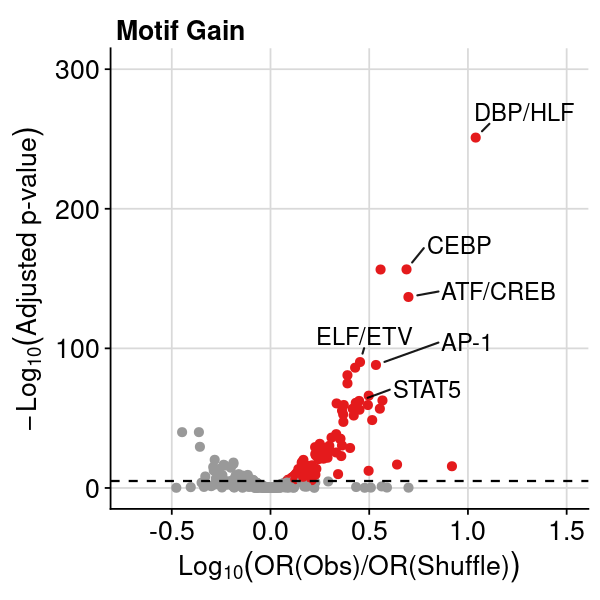

In [93]:
dat = dat_res_motif_label
dat = dat %>% dplyr::filter(Direction == "Count_Gain")

### motifs to label (match your Motif_Name strings)
vec_txt_motif = c(
    "AC0403:DBP/HLF:bZIP",
    "AC0402:CEBPB/CEBPE:bZIP",
    "AC0547:ATF/CREB:bZIP",
    "AC0242:FOSL/JUND:bZIP",
    "AC0626:ELF/ETV:Ets",
    "AC0212:STAT/STAT5A:STAT"
)
tmp = dat %>%
    dplyr::filter(Motif_Name %in% vec_txt_motif) %>%
    dplyr::mutate(
        Label = dplyr::case_when(
            grepl("DBP/HLF", Motif_Name) ~ "DBP/HLF",
            grepl("CEBPB/CEBPE", Motif_Name) ~ "CEBP",
            grepl("ATF/CREB", Motif_Name) ~ "ATF/CREB",
            grepl("FOSL/JUND", Motif_Name) ~ "AP-1",
            grepl("ELF/ETV", Motif_Name) ~ "ELF/ETV",
            grepl("STAT", Motif_Name) ~ "STAT5",
            TRUE ~ Motif_Name
        )
    )

gpt = ggplot(dat, aes(x = log10Beta, y = nlog10Padj)) +
    geom_point(aes(color = Hit_Type), size = 2) +
    geom_hline(yintercept = num_cut_padj, linetype = "dashed") +
    theme_cowplot() +
    background_grid() +
    THEME_TEXT +
    theme(
        strip.background = element_blank(),
        strip.text = element_text(size = 16, hjust = 0, face = "bold")
    ) +
    facet_grid(
        . ~ Direction,
        labeller = labeller(
            Direction = c(
                "Count_Gain" = "Motif Gain",
                "Count_Loss" = "Motif Loss"
            )
        )
    ) +
    scale_color_manual(
        values = c(
            "NotSignif" = "grey60",
            "Gain_Hit"  = "#e41a1c",
            "Loss_Hit"  = "#377eb8"
        ),
        guide = "none"
    ) + 
    ggrepel::geom_text_repel(
        data = tmp,
        aes(x = log10Beta, y = nlog10Padj, label = Label),
        size = 5,
        nudge_x = 0.3,
        nudge_y = 15,            # force distance from point
        box.padding = 0.6,
        point.padding = 0.6,
        min.segment.length = 0,  # draw segment (even if short)
        segment.color = "black",
        segment.size  = 0.6,
        segment.alpha = 0.9,
        max.overlaps = Inf
    ) + 
    labs(
        x = expression(Log[10]("OR(Obs)/OR(Shuffle)")),
        y = expression(-Log[10]("Adjusted p-value"))
    )

### assign and show
gpt_export_gain = gpt
options(repr.plot.height=5, repr.plot.width=5)
gpt = gpt + ylim(0, 300) + xlim(-0.7, 1.5)
print(gpt)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


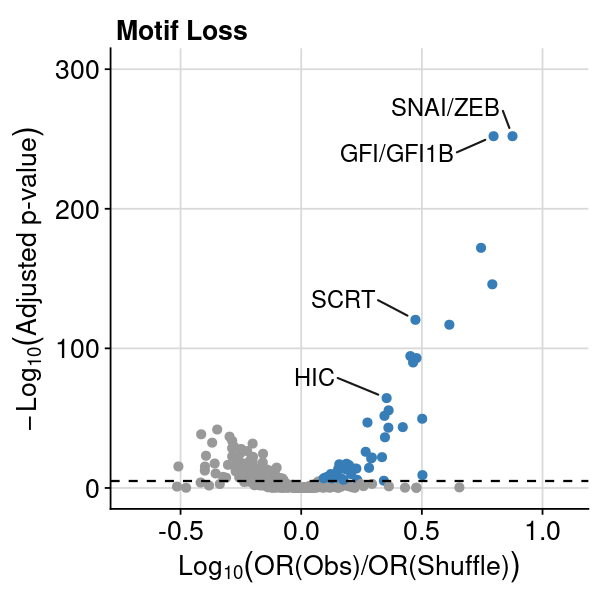

In [92]:
dat = dat_res_motif_label
dat = dat %>% dplyr::filter(Direction == "Count_Loss")

### motifs to label (match your Motif_Name strings)
vec_txt_motif = c(
    "AC0606:SNAI/ZEB:C2H2_ZF",
    "AC0526:GFI/GFI1B:C2H2_ZF",
    "AC0605:SCRT:C2H2_ZF",
    "AC0084:HIC:C2H2_ZF"
)
tmp = dat %>%
    dplyr::filter(Motif_Name %in% vec_txt_motif) %>%
    dplyr::mutate(
        Label = dplyr::case_when(
            grepl("SNAI/ZEB", Motif_Name) ~ "SNAI/ZEB",
            grepl("GFI/GFI1B", Motif_Name) ~ "GFI/GFI1B",
            grepl("SCRT", Motif_Name) ~ "SCRT",
            grepl("HIC", Motif_Name) ~ "HIC",
            TRUE ~ Motif_Name
        )
    )

gpt = ggplot(dat, aes(x = log10Beta, y = nlog10Padj)) +
    geom_point(aes(color = Hit_Type), size = 2) +
    geom_hline(yintercept = num_cut_padj, linetype = "dashed") +
    theme_cowplot() +
    background_grid() +
    THEME_TEXT +
    theme(
        strip.background = element_blank(),
        strip.text = element_text(size = 16, hjust = 0, face = "bold")
    ) +
    facet_grid(
        . ~ Direction,
        labeller = labeller(
            Direction = c(
                "Count_Gain" = "Motif Gain",
                "Count_Loss" = "Motif Loss"
            )
        )
    ) +
    scale_color_manual(
        values = c(
            "NotSignif" = "grey60",
            "Gain_Hit"  = "#e41a1c",
            "Loss_Hit"  = "#377eb8"
        ),
        guide = "none"
    ) +
    ggrepel::geom_text_repel(
        data = tmp,
        aes(x = log10Beta, y = nlog10Padj, label = Label),
        size = 5,
        nudge_x = -0.3,
        nudge_y = 15,            # force distance from point
        box.padding = 0.6,
        point.padding = 0.6,
        min.segment.length = 0,  # draw segment (even if short)
        segment.color = "black",
        segment.size  = 0.6,
        segment.alpha = 0.9,
        max.overlaps = Inf
    ) +
    labs(
        x = expression(Log[10]("OR(Obs)/OR(Shuffle)")),
        y = expression(-Log[10]("Adjusted p-value"))
    )

gpt_export_loss = gpt
options(repr.plot.height=5, repr.plot.width=5)
gpt = gpt + ylim(0, 300) + xlim(-0.7, 1.1)
print(gpt)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


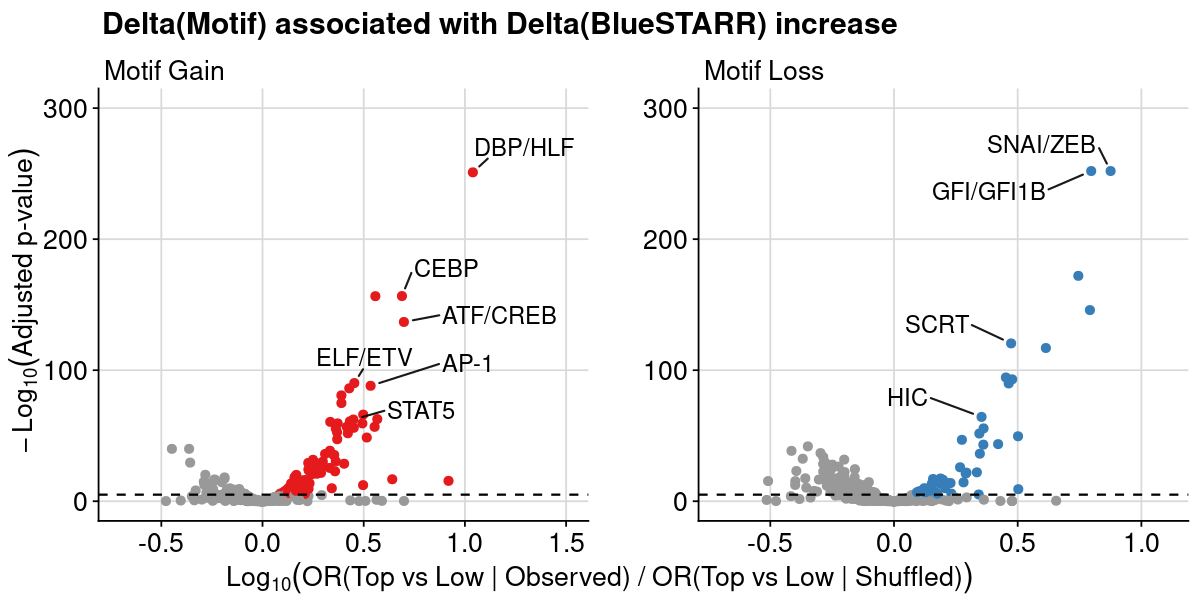

In [85]:
gpt1 = gpt_export_gain + 
    ylim(0, 300) + 
    xlim(-0.7, 1.5) + 
    labs(x = "", y = "", title = "") +
    theme(strip.text = element_text(size = 16, hjust = 0, face = "plain"))

gpt2 = gpt_export_loss + 
    ylim(0, 300) + 
    xlim(-0.7, 1.1) + 
    labs(x = "", y = "", title = "") +
    theme(strip.text = element_text(size = 16, hjust = 0, face = "plain"))

lst = list(gpt1, gpt2)
plt = plot_grid(plotlist = lst, ncol = 2, align = "h")

plt = ggdraw(plt) +
    ### Title
    draw_label(
        "Delta(Motif) associated with Delta(BlueSTARR) increase",
        x = 0.085,
        y = 0.98,
        hjust = 0,
        vjust = 1,
        size = 18,
        fontface = "bold"
    ) +

    ### X label
    draw_label(
        expression(Log[10]("OR(Top vs Low | Observed) / OR(Top vs Low | Shuffled)")),
        x = 0.5,
        y = 0.01,
        hjust = 0.5,
        vjust = 0,
        size = 16
    ) +

    ### Y label
    draw_label(
        expression(-Log[10]("Adjusted p-value")),
        x = 0.02,
        y = 0.5,
        angle = 90,
        hjust = 0.5,
        vjust = 0.5,
        size = 16
    )


options(repr.plot.height=5, repr.plot.width=10)
print(plt)